# Wang et al. (2021) ESR 论文复现
## Revisiting the Permian seawater ⁸⁷Sr/⁸⁶Sr record: New perspectives from brachiopod proxy data and stochastic oceanic box models

---

本Notebook复现Wang等人(2021)发表在Earth-Science Reviews上的研究，包括：

1. **四端元海洋箱模型** - 河流、高温热液、低温热液、成岩作用
2. **蒙特卡洛随机模拟** - 探索参数空间
3. **七种情景分析** - 测试不同约束条件
4. **敏感性分析** - 各参数对海水Sr同位素的影响

引用：Wang, W.Q., et al. (2021). Earth-Science Reviews 218: 103679

## 1. 导入必要的库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# 添加项目根目录到路径
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# 导入Sr同位素系统
from systems.sr import SrIsotopeSystem, SrFluxConfig
from systems.sr.parameters import STOCHASTIC_RANGES, PARAMETER_UNCERTAINTIES

# 设置matplotlib中文字体（如果需要）
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ 导入完成")

✓ 导入完成


## 2. 论文核心公式

### 2.1 质量平衡方程

稳态条件下的Sr质量平衡：

$$F_{in} = F_{riv} + F_{highT} + F_{lowT} + F_{dia} = F_{out}$$

海水⁸⁷Sr/⁸⁶Sr比值：

$$R_{ocean} = \frac{F_{riv}R_{riv} + F_{highT}R_{highT} + F_{lowT}R_{lowT} + F_{dia}R_{dia}}{F_{riv} + F_{highT} + F_{lowT} + F_{dia}}$$

### 2.2 端元参数（Table 1）

In [2]:
# 显示论文Table 1的参数范围
print("=== Wang et al. (2021) Table 1 参数范围 ===\n")

param_info = {
    'F_river': {'range': (10e9, 190e9), 'unit': 'mol/yr', 'uncertainty': '10%', 'modern': 47.6e9},
    'R_river': {'range': (0.7025, 0.75), 'unit': '', 'uncertainty': '±0.0005', 'modern': 0.71107},
    'F_hydrothermal_lowT': {'range': (2.5e9, 40e9), 'unit': 'mol/yr', 'uncertainty': '10%', 'modern': 10e9},
    'R_hydrothermal_lowT': {'range': (0.7025, 0.7084), 'unit': '', 'uncertainty': '±0.0005', 'modern': 0.7084},
    'F_hydrothermal_highT': {'range': (2e9, 35e9), 'unit': 'mol/yr', 'uncertainty': '10%', 'modern': 8.04e9},
    'R_hydrothermal_highT': {'range': (0.703, 0.704), 'unit': '', 'uncertainty': '±0.0001', 'modern': 0.7037},
    'F_diagenetic': {'range': (3.4e9, 3.4e9), 'unit': 'mol/yr', 'uncertainty': 'constant', 'modern': 3.4e9},
    'R_diagenetic': {'range': (0.7084, 0.7084), 'unit': '', 'uncertainty': 'constant', 'modern': 0.7084},
}

print(f"{'Parameter':<25} {'Range':<30} {'1σ':<15} {'Modern':<15}")
print("-" * 85)
for name, info in param_info.items():
    r = info['range']
    range_str = f"[{r[0]:.4e}, {r[1]:.4e}]" if r[0] < 0.1 else f"[{r[0]:.5f}, {r[1]:.5f}]"
    modern_str = f"{info['modern']:.4e}" if info['modern'] < 0.1 else f"{info['modern']:.5f}"
    print(f"{name:<25} {range_str:<30} {info['uncertainty']:<15} {modern_str:<15}")

=== Wang et al. (2021) Table 1 参数范围 ===

Parameter                 Range                          1σ              Modern         
-------------------------------------------------------------------------------------
F_river                   [10000000000.00000, 190000000000.00000] 10%             47600000000.00000
R_river                   [0.70250, 0.75000]             ±0.0005         0.71107        
F_hydrothermal_lowT       [2500000000.00000, 40000000000.00000] 10%             10000000000.00000
R_hydrothermal_lowT       [0.70250, 0.70840]             ±0.0005         0.70840        
F_hydrothermal_highT      [2000000000.00000, 35000000000.00000] 10%             8040000000.00000
R_hydrothermal_highT      [0.70300, 0.70400]             ±0.0001         0.70370        
F_diagenetic              [3400000000.00000, 3400000000.00000] constant        3400000000.00000
R_diagenetic              [0.70840, 0.70840]             constant        0.70840        


## 3. 现代海洋Sr循环

In [3]:
# 创建Sr同位素系统
sr = SrIsotopeSystem(scenario='modern')

# 使用现代参数计算
modern_ratio = sr.calculate_seawater_ratio()
observed_modern = 0.70917

print("=== 现代海洋Sr循环 ===\n")
print(f"计算的海水 ⁸⁷Sr/⁸⁶Sr: {modern_ratio:.5f}")
print(f"观测的海水 ⁸⁷Sr/⁸⁶Sr: {observed_modern:.5f}")
print(f"偏差: {(modern_ratio - observed_modern)*10000:+.2f} ppm\n")

# 显示各端元贡献
print("各端元通量贡献:")
fluxes = {
    'Riverine': (47.6e9, 0.71107),
    'High-T hydrothermal': (8.04e9, 0.7037),
    'Low-T hydrothermal': (10e9, 0.7084),
    'Diagenetic': (3.4e9, 0.7084),
}

total_flux = sum(f for f, r in fluxes.values())
weighted_sum = sum(f * r for f, r in fluxes.values())

print(f"{'End-member':<25} {'Flux (10⁹ mol/yr)':<20} {'⁸⁷Sr/⁸⁶Sr':<15} {'% of total':<12}")
print("-" * 72)
for name, (flux, ratio) in fluxes.items():
    pct = flux / total_flux * 100
    print(f"{name:<25} {flux/1e9:<20.2f} {ratio:<15.5f} {pct:<12.1f}")
print("-" * 72)
print(f"{'Total':<25} {total_flux/1e9:<20.2f}")

=== 现代海洋Sr循环 ===

计算的海水 ⁸⁷Sr/⁸⁶Sr: 0.70969
观测的海水 ⁸⁷Sr/⁸⁶Sr: 0.70917
偏差: +5.24 ppm

各端元通量贡献:
End-member                Flux (10⁹ mol/yr)    ⁸⁷Sr/⁸⁶Sr       % of total  
------------------------------------------------------------------------
Riverine                  47.60                0.71107         68.9        
High-T hydrothermal       8.04                 0.70370         11.6        
Low-T hydrothermal        10.00                0.70840         14.5        
Diagenetic                3.40                 0.70840         4.9         
------------------------------------------------------------------------
Total                     69.04               


### 3.1 可视化各端元贡献

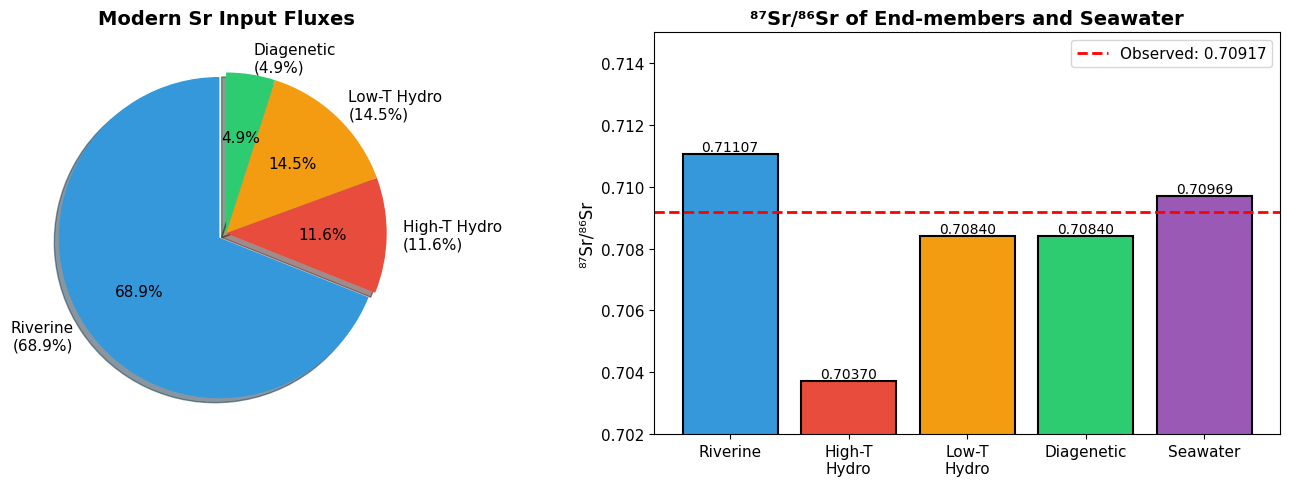

✓ 图表已保存到 ./output/modern_sr_cycle.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：通量饼图
ax1 = axes[0]
labels = ['Riverine\n(68.9%)', 'High-T Hydro\n(11.6%)', 'Low-T Hydro\n(14.5%)', 'Diagenetic\n(4.9%)']
sizes = [47.6e9, 8.04e9, 10e9, 3.4e9]
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
explode = (0.05, 0, 0, 0)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.set_title('Modern Sr Input Fluxes', fontsize=14, fontweight='bold')

# 右图：同位素组成对比
ax2 = axes[1]
end_members = ['Riverine', 'High-T\nHydro', 'Low-T\nHydro', 'Diagenetic', 'Seawater']
ratios = [0.71107, 0.7037, 0.7084, 0.7084, modern_ratio]
colors_bar = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6']

bars = ax2.bar(end_members, ratios, color=colors_bar, edgecolor='black', linewidth=1.5)
ax2.axhline(y=observed_modern, color='red', linestyle='--', linewidth=2, label=f'Observed: {observed_modern:.5f}')
ax2.set_ylabel('⁸⁷Sr/⁸⁶Sr', fontsize=12)
ax2.set_title('⁸⁷Sr/⁸⁶Sr of End-members and Seawater', fontsize=14, fontweight='bold')
ax2.legend()
ax2.set_ylim(0.702, 0.715)

# 在柱状图上添加数值
for bar, ratio in zip(bars, ratios):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{ratio:.5f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('./output/modern_sr_cycle.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 图表已保存到 ./output/modern_sr_cycle.png")

## 4. 二叠纪海水Sr同位素演化

In [7]:
# 基于论文数据的二叠纪Sr同位素演化
permian_data = pd.DataFrame({
    'Age_Ma': [299, 295, 290, 283, 273, 265, 259, 256, 252],
    'Stage': ['Asselian', 'Sakmarian', 'Artinskian', 'Kungurian', 
              'Roadian', 'Wordian', 'Capitanian', 'Wuchiapingian', 'Changhsingian'],
    'Sr_ratio': [0.70827, 0.7080, 0.7075, 0.7070, 0.7069, 0.70683, 0.70685, 0.7070, 0.70717],
    'Period': ['Cisuralian']*4 + ['Guadalupian']*3 + ['Lopingian']*2
})

print("=== 二叠纪海水Sr同位素记录（基于Wang et al., 2021）===\n")
print(permian_data.to_string(index=False))

# 计算变化率
permian_data['dSr_dt'] = np.gradient(permian_data['Sr_ratio'], permian_data['Age_Ma'])

print("\n=== 变化率 ===")
print(f"Asselian to Capitanian (下降期): {(0.70683 - 0.70827) / (259 - 299) * 1e6:.2f} × 10⁻⁶/Myr")
print(f"Capitanian to Changhsingian (上升期): {(0.70717 - 0.70683) / (252 - 259) * 1e6:.2f} × 10⁻⁶/Myr")

=== 二叠纪海水Sr同位素记录（基于Wang et al., 2021）===

 Age_Ma         Stage  Sr_ratio      Period
    299      Asselian   0.70827  Cisuralian
    295     Sakmarian   0.70800  Cisuralian
    290    Artinskian   0.70750  Cisuralian
    283     Kungurian   0.70700  Cisuralian
    273       Roadian   0.70690 Guadalupian
    265       Wordian   0.70683 Guadalupian
    259    Capitanian   0.70685 Guadalupian
    256 Wuchiapingian   0.70700   Lopingian
    252 Changhsingian   0.70717   Lopingian

=== 变化率 ===
Asselian to Capitanian (下降期): 36.00 × 10⁻⁶/Myr
Capitanian to Changhsingian (上升期): -48.57 × 10⁻⁶/Myr


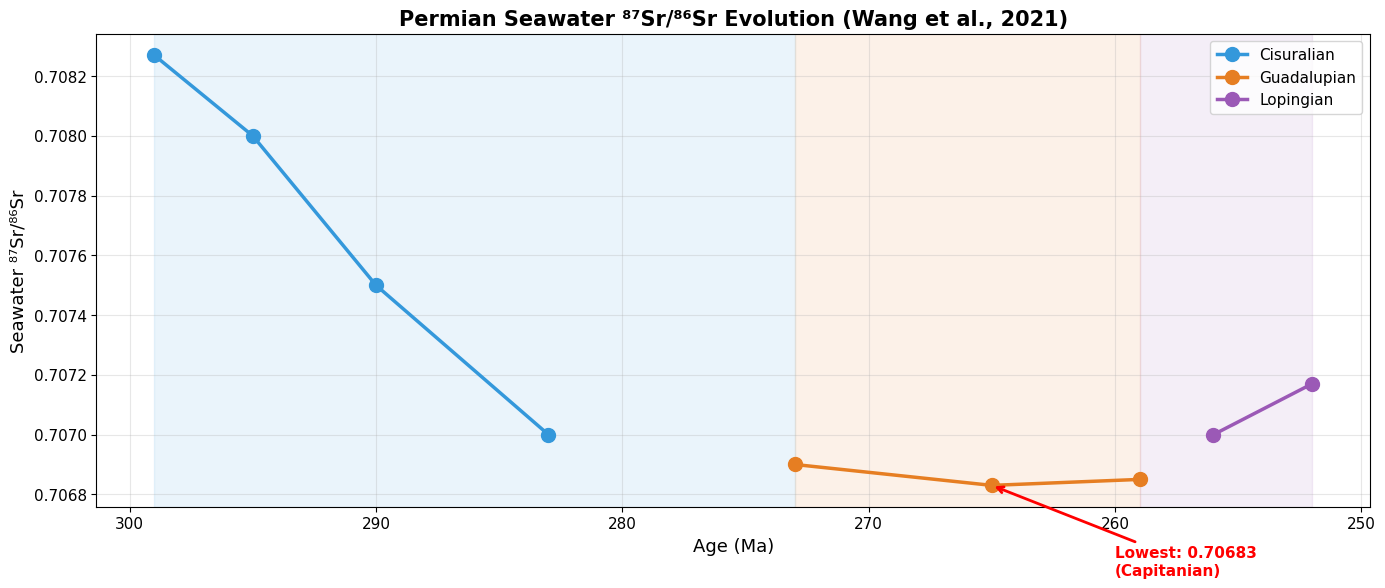

✓ 图表已保存到 ./output/permian_sr_evolution.png


In [9]:
# 绘制二叠纪Sr同位素演化曲线
fig, ax = plt.subplots(figsize=(14, 6))

# 按地质年代着色
colors_period = {'Cisuralian': '#3498db', 'Guadalupian': '#e67e22', 'Lopingian': '#9b59b6'}

for period in permian_data['Period'].unique():
    mask = permian_data['Period'] == period
    ax.plot(permian_data.loc[mask, 'Age_Ma'], 
            permian_data.loc[mask, 'Sr_ratio'], 
            'o-', color=colors_period[period], linewidth=2.5, markersize=10,
            label=period)

# 标注最低值
min_idx = permian_data['Sr_ratio'].idxmin()
min_age = permian_data.loc[min_idx, 'Age_Ma']
min_sr = permian_data.loc[min_idx, 'Sr_ratio']
ax.annotate(f'Lowest: {min_sr:.5f}\n(Capitanian)', 
            xy=(min_age, min_sr), xytext=(min_age-5, min_sr-0.0003),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, color='red', fontweight='bold')

ax.set_xlabel('Age (Ma)', fontsize=13)
ax.set_ylabel('Seawater ⁸⁷Sr/⁸⁶Sr', fontsize=13)
ax.set_title('Permian Seawater ⁸⁷Sr/⁸⁶Sr Evolution (Wang et al., 2021)', 
             fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# 添加地质年代背景色
ax.axvspan(299, 273, alpha=0.1, color='#3498db', label='Cisuralian')
ax.axvspan(273, 259, alpha=0.1, color='#e67e22', label='Guadalupian')
ax.axvspan(259, 252, alpha=0.1, color='#9b59b6', label='Lopingian')

plt.tight_layout()
plt.savefig('./output/permian_sr_evolution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 图表已保存到 ./output/permian_sr_evolution.png")

## 5. 蒙特卡洛随机模拟

复现论文中的随机海洋箱模型方法：
- 每次从参数范围内随机采样
- 计算对应的Sr同位素比值
- 统计成功运行的参数分布

In [10]:
# 运行蒙特卡洛模拟
print("=== 运行蒙特卡洛随机模拟 ===\n")

sr_permian = SrIsotopeSystem(scenario='permian')

# 运行5000次（论文中使用的是5000次）
n_runs = 5000
print(f"运行 {n_runs} 次蒙特卡洛模拟...\n")

result_mc = sr_permian.monte_carlo_simulation(
    time_span=(299, 252),
    n_runs=n_runs,
    n_time_points=50,
    filter_by_data=False,  # 不过滤，查看完整参数空间
    verbose=False
)

if result_mc.success:
    print(f"✓ 模拟完成")
    print(f"  成功率: {result_mc.data['success_rate']:.2%}")
    print(f"  成功运行次数: {result_mc.data['n_successful']}/{n_runs}\n")
    
    # 显示参数统计
    print("参数统计结果:")
    print(f"{'Parameter':<25} {'Mean':<15} {'Std':<15}")
    print("-" * 55)
    for param_name in ['F_river', 'R_river', 'F_hydrothermal_highT']:
        if param_name in result_mc.statistics:
            s = result_mc.statistics[param_name]
            print(f"{param_name:<25} {s['mean']:<15.3e} {s['std']:<15.3e}")
else:
    print(f"✗ 模拟失败: {result_mc.message}")

=== 运行蒙特卡洛随机模拟 ===

运行 5000 次蒙特卡洛模拟...

✓ 模拟完成
  成功率: 100.00%
  成功运行次数: 5000/5000

参数统计结果:
Parameter                 Mean            Std            
-------------------------------------------------------
F_river                   1.008e+11       5.185e+10      
R_river                   7.261e-01       1.368e-02      
F_hydrothermal_highT      1.839e+10       9.576e+09      


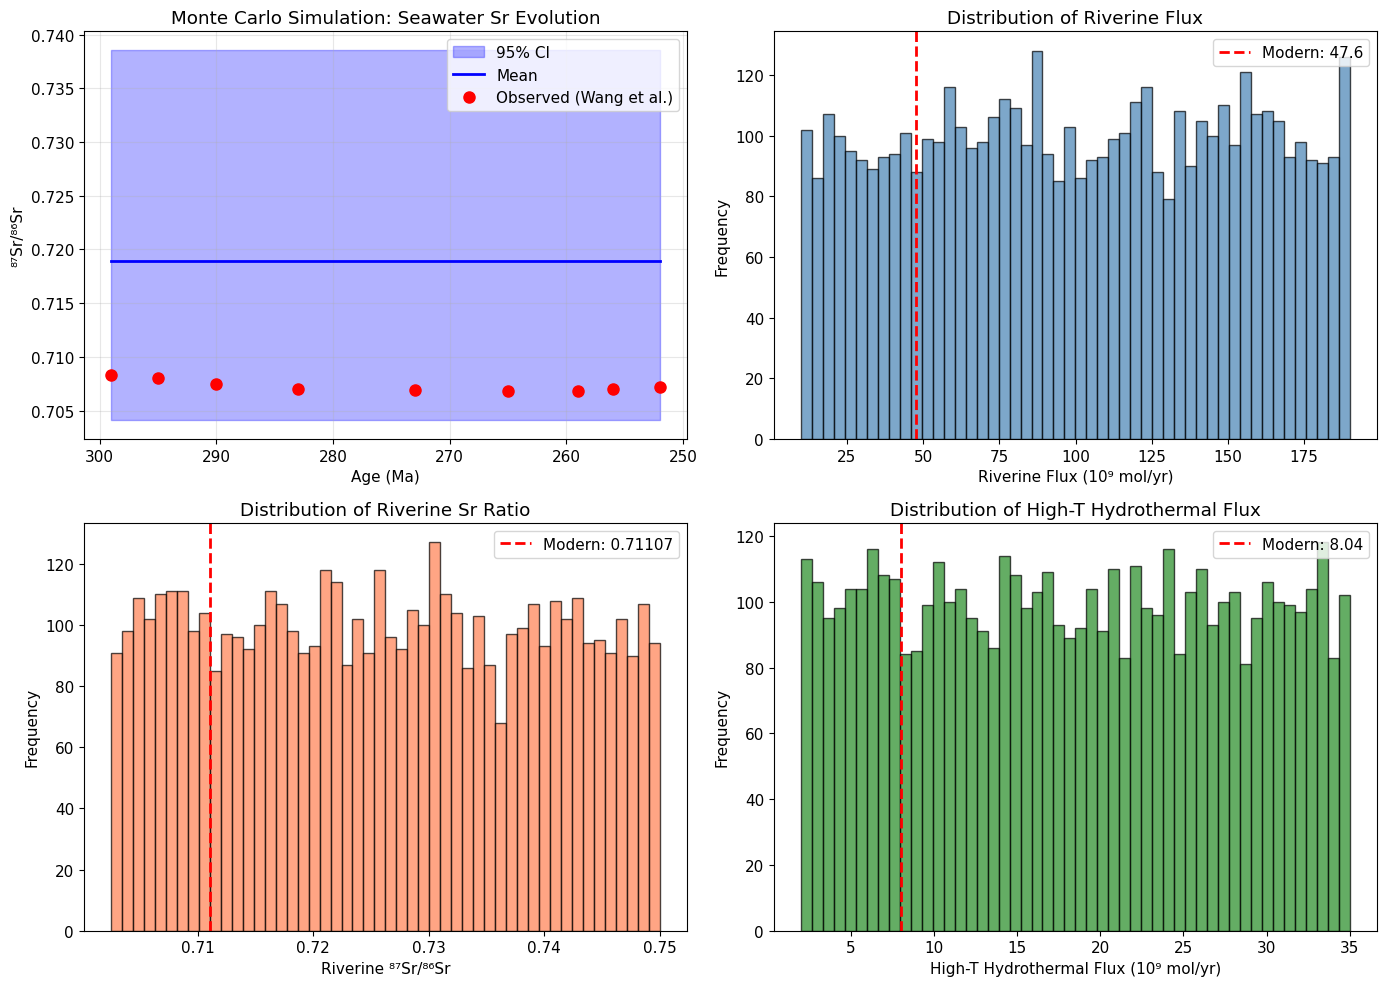

✓ 图表已保存到 ./output/monte_carlo_results.png


In [11]:
# 可视化蒙特卡洛结果
if result_mc.success:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 图1: Sr同位素演化
    ax1 = axes[0, 0]
    ages = result_mc.time
    mean_ratio = result_mc.data['mean_ratio']
    std_ratio = result_mc.data['std_ratio']
    p25 = result_mc.data['percentile_2.5']
    p975 = result_mc.data['percentile_97.5']
    
    ax1.fill_between(ages, p25, p975, alpha=0.3, color='blue', label='95% CI')
    ax1.plot(ages, mean_ratio, 'b-', linewidth=2, label='Mean')
    ax1.plot(permian_data['Age_Ma'], permian_data['Sr_ratio'], 'ro', 
             markersize=8, label='Observed (Wang et al.)')
    ax1.set_xlabel('Age (Ma)')
    ax1.set_ylabel('⁸⁷Sr/⁸⁶Sr')
    ax1.set_title('Monte Carlo Simulation: Seawater Sr Evolution')
    ax1.legend()
    ax1.invert_xaxis()
    ax1.grid(True, alpha=0.3)
    
    # 图2: 河流通量分布
    ax2 = axes[0, 1]
    F_river_vals = result_mc.get_parameter_array('F_river') / 1e9
    ax2.hist(F_river_vals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax2.axvline(47.6, color='red', linestyle='--', linewidth=2, label='Modern: 47.6')
    ax2.set_xlabel('Riverine Flux (10⁹ mol/yr)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Riverine Flux')
    ax2.legend()
    
    # 图3: 河流同位素分布
    ax3 = axes[1, 0]
    R_river_vals = result_mc.get_parameter_array('R_river')
    ax3.hist(R_river_vals, bins=50, color='coral', edgecolor='black', alpha=0.7)
    ax3.axvline(0.71107, color='red', linestyle='--', linewidth=2, label='Modern: 0.71107')
    ax3.set_xlabel('Riverine ⁸⁷Sr/⁸⁶Sr')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Distribution of Riverine Sr Ratio')
    ax3.legend()
    
    # 图4: 高温热液通量分布
    ax4 = axes[1, 1]
    F_highT_vals = result_mc.get_parameter_array('F_hydrothermal_highT') / 1e9
    ax4.hist(F_highT_vals, bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
    ax4.axvline(8.04, color='red', linestyle='--', linewidth=2, label='Modern: 8.04')
    ax4.set_xlabel('High-T Hydrothermal Flux (10⁹ mol/yr)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Distribution of High-T Hydrothermal Flux')
    ax4.legend()
    
    plt.tight_layout()
    plt.savefig('./output/monte_carlo_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ 图表已保存到 ./output/monte_carlo_results.png")

## 6. 情景分析

Wang et al. (2021) 测试了7种不同约束情景：

| 情景 | 描述 | 主要发现 |
|------|------|----------|
| Scenario 1 | 所有参数可变 | 需要河流同位素显著下降 |
| Scenario 2 | 固定河流同位素 | 需要河流通量显著下降 |
| Scenario 3 | 固定河流通量 | 需要河流同位素显著下降 |
| Scenario 4 | 固定高温热液通量 | 需要河流同位素下降 |
| Scenario 5 | 固定低温热液通量 | 需要河流同位素下降 |
| Scenario 6 | 固定所有热液通量 | 需要河流同位素下降 |
| Scenario 7 | 固定河流参数 | **需要热液通量显著增加** |

In [13]:
# 运行所有7种情景分析
print("=== 运行七种情景分析 ===\n")

scenarios = ['scenario1', 'scenario2', 'scenario3', 'scenario4', 
             'scenario5', 'scenario6', 'scenario7']

scenario_results = {}

for scenario_name in scenarios:
    print(f"运行 {scenario_name}...")
    result = sr_permian.scenario_analysis(
        scenario_name=scenario_name,
        time_span=(299, 252),
        n_runs=2000,
        filter_by_data=False,
        verbose=False
    )
    
    if result.success:
        scenario_results[scenario_name] = result
        n_success = result.data['n_successful']
        print(f"  ✓ 成功运行: {n_success}/2000 ({n_success/2000:.1%})")
    else:
        print(f"  ✗ 失败: {result.message}")

print("\n=== 情景分析完成 ===")

=== 运行七种情景分析 ===

运行 scenario1...

运行情景: scenario1
可变参数: ['F_river', 'R_river', 'F_hydrothermal_lowT', 'R_hydrothermal_lowT', 'F_hydrothermal_highT', 'R_hydrothermal_highT']
  ✓ 成功运行: 2000/2000 (100.0%)
运行 scenario2...

运行情景: scenario2
可变参数: ['F_river', 'F_hydrothermal_lowT', 'R_hydrothermal_lowT', 'F_hydrothermal_highT', 'R_hydrothermal_highT']
  ✓ 成功运行: 2000/2000 (100.0%)
运行 scenario3...

运行情景: scenario3
可变参数: ['R_river', 'F_hydrothermal_lowT', 'R_hydrothermal_lowT', 'F_hydrothermal_highT', 'R_hydrothermal_highT']
  ✓ 成功运行: 2000/2000 (100.0%)
运行 scenario4...

运行情景: scenario4
可变参数: ['F_river', 'R_river', 'F_hydrothermal_lowT', 'R_hydrothermal_lowT', 'R_hydrothermal_highT']
  ✓ 成功运行: 2000/2000 (100.0%)
运行 scenario5...

运行情景: scenario5
可变参数: ['F_river', 'R_river', 'R_hydrothermal_lowT', 'F_hydrothermal_highT', 'R_hydrothermal_highT']
  ✓ 成功运行: 2000/2000 (100.0%)
运行 scenario6...

运行情景: scenario6
可变参数: ['F_river', 'R_river', 'R_hydrothermal_lowT', 'R_hydrothermal_highT']
  ✓ 成功运行: 2000/20

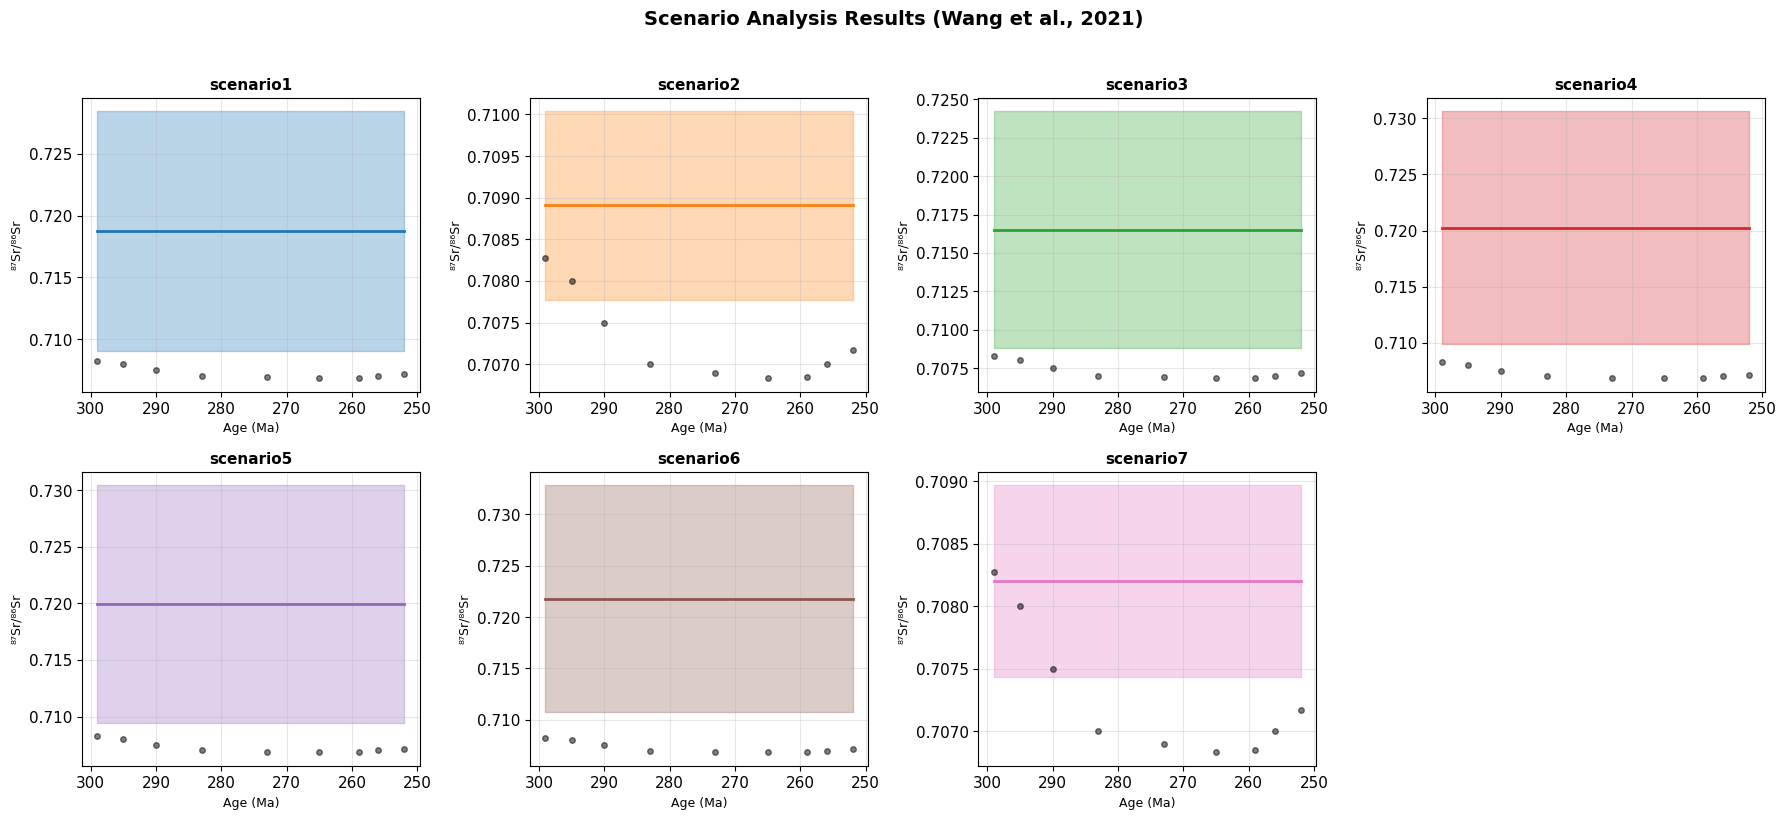

✓ 图表已保存到 ./output/scenario_analysis.png


In [14]:
# 可视化各情景的参数分布
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (scenario_name, result) in enumerate(scenario_results.items()):
    ax = axes[idx]
    
    # 绘制该情景下的Sr同位素均值演化
    if result.success:
        ages = result.time
        mean_sr = result.data['mean_ratio']
        std_sr = result.data['std_ratio']
        
        ax.fill_between(ages, mean_sr - std_sr, mean_sr + std_sr, 
                        alpha=0.3, color=f'C{idx}')
        ax.plot(ages, mean_sr, color=f'C{idx}', linewidth=2)
        
        # 叠加观测数据
        ax.plot(permian_data['Age_Ma'], permian_data['Sr_ratio'], 
                'ko', markersize=4, alpha=0.5)
    
    ax.set_title(f'{scenario_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Age (Ma)', fontsize=9)
    ax.set_ylabel('⁸⁷Sr/⁸⁶Sr', fontsize=9)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)

# 隐藏最后一个子图
axes[-1].axis('off')

plt.suptitle('Scenario Analysis Results (Wang et al., 2021)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./output/scenario_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 图表已保存到 ./output/scenario_analysis.png")

## 7. 敏感性分析

分析各参数对海水Sr同位素的影响程度

In [16]:
# 对关键参数进行敏感性分析
print("=== 参数敏感性分析 ===\n")

sensitivity_params = [
    ('R_river', (0.705, 0.725), 'Riverine ⁸⁷Sr/⁸⁶Sr'),
    ('F_river', (10e9, 150e9), 'Riverine Flux (mol/yr)'),
    ('F_highT', (2e9, 35e9), 'High-T Hydrothermal Flux (mol/yr)'),
    ('R_highT', (0.703, 0.704), 'High-T Hydrothermal ⁸⁷Sr/⁸⁶Sr'),
]

sens_results = {}

for param_name, param_range, label in sensitivity_params:
    print(f"分析 {param_name}...")
    result = sr_permian.sensitivity_analysis(
        param_name=param_name,
        param_range=param_range,
        n_steps=100
    )
    sens_results[param_name] = result
    
    # 计算敏感性系数
    sr_range = result.data['sr_ratios'].max() - result.data['sr_ratios'].min()
    param_span = param_range[1] - param_range[0]
    sensitivity_coeff = sr_range / param_span
    
    print(f"  敏感性系数: {sensitivity_coeff:.6e} ΔR_sw/Δparam")

print("\n=== 分析完成 ===")

=== 参数敏感性分析 ===

分析 R_river...
  敏感性系数: 6.894554e-01 ΔR_sw/Δparam
分析 F_river...
  敏感性系数: 1.763108e-14 ΔR_sw/Δparam
分析 F_highT...
  敏感性系数: 6.841799e-14 ΔR_sw/Δparam
分析 R_highT...
  敏感性系数: 1.164542e-01 ΔR_sw/Δparam

=== 分析完成 ===


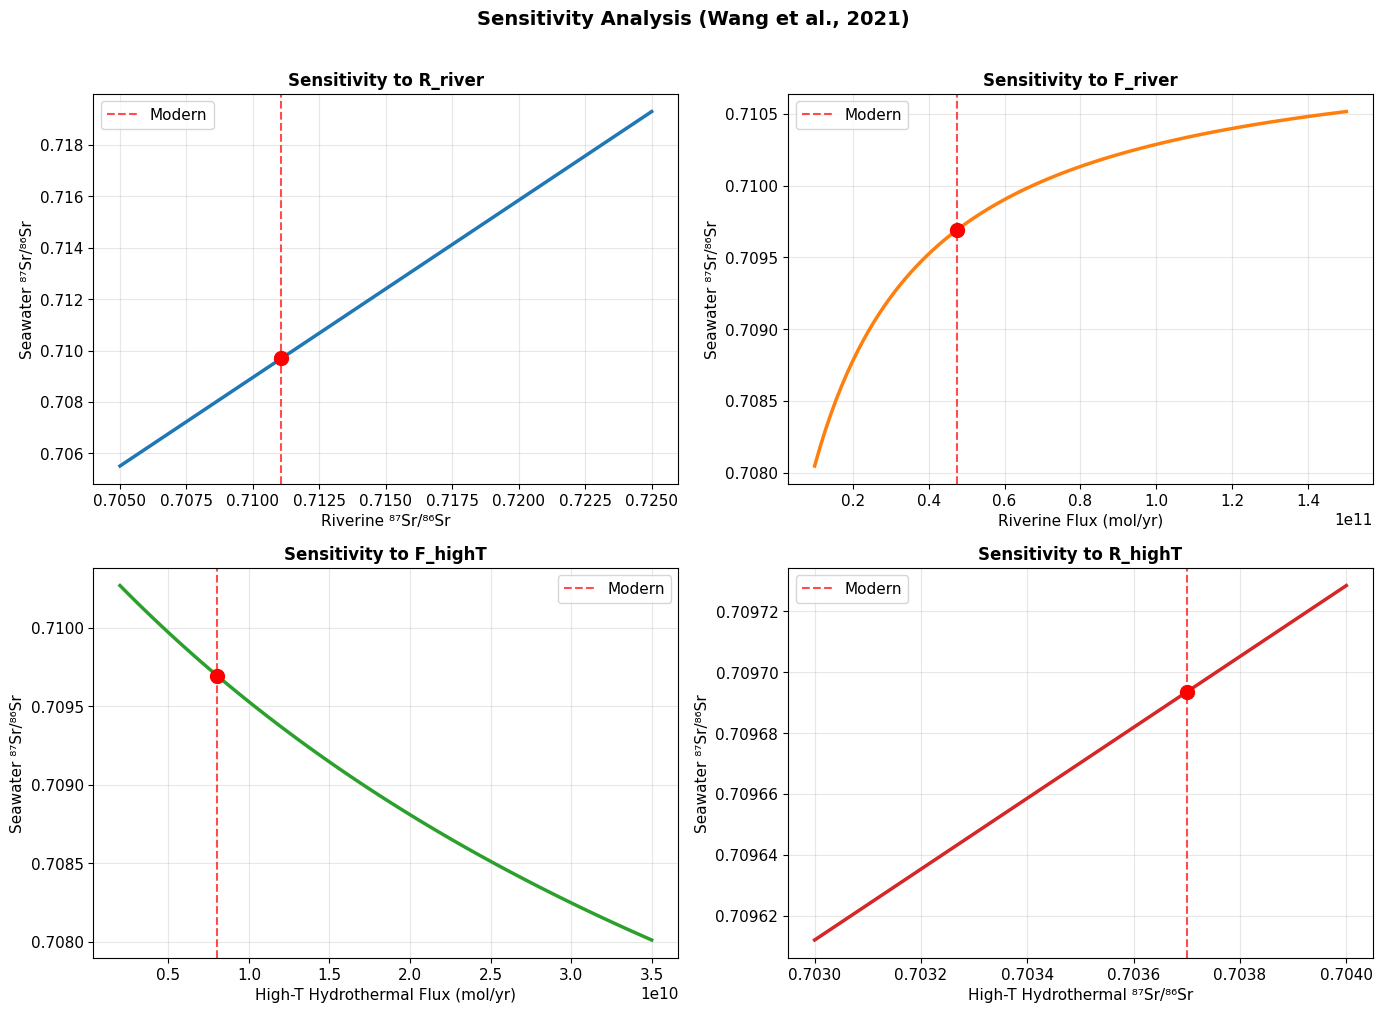

✓ 图表已保存到 ./output/sensitivity_analysis.png


In [17]:
# 绘制敏感性分析结果
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (param_name, result) in enumerate(sens_results.items()):
    ax = axes[idx // 2, idx % 2]
    
    param_vals = result.data['param_values']
    sr_vals = result.data['sr_ratios']
    
    # 绘制敏感性曲线
    ax.plot(param_vals, sr_vals, linewidth=2.5, color=f'C{idx}')
    
    # 标注现代值
    modern_values = {
        'R_river': 0.71107,
        'F_river': 47.6e9,
        'F_highT': 8.04e9,
        'R_highT': 0.7037,
    }
    modern_val = modern_values.get(param_name, 0)
    modern_sr = sr.calculate_seawater_ratio(**{param_name: modern_val})
    
    ax.axvline(modern_val, color='red', linestyle='--', alpha=0.7, label='Modern')
    ax.plot(modern_val, modern_sr, 'ro', markersize=10)
    
    ax.set_xlabel(sensitivity_params[idx][2], fontsize=11)
    ax.set_ylabel('Seawater ⁸⁷Sr/⁸⁶Sr', fontsize=11)
    ax.set_title(f'Sensitivity to {param_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Sensitivity Analysis (Wang et al., 2021)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./output/sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 图表已保存到 ./output/sensitivity_analysis.png")

## 8. 关键发现总结

根据Wang et al. (2021)的研究结论：

In [18]:
# 生成总结报告
print("="*70)
print("Wang et al. (2021) ESR 论文复现 - 关键发现总结")
print("="*70)

print("\n1. 二叠纪Sr同位素演化特征:")
print("   - 早二叠世-中二叠世: 持续下降")
print(f"     从 Asselian ({permian_data.iloc[0]['Sr_ratio']:.5f}) ")
print(f"     到 Capitanian ({permian_data.iloc[6]['Sr_ratio']:.5f})")
print(f"     变化率: ~{(0.70683 - 0.70827) / (259 - 299) * 1e6:.1f} × 10⁻⁶/Myr")
print("   - 晚二叠世: 上升")
print(f"     从 Capitanian 到 Changhsingian ({permian_data.iloc[-1]['Sr_ratio']:.5f})")

print("\n2. 模型结果:")
if result_mc.success:
    print(f"   - 蒙特卡洛模拟成功运行: {result_mc.data['n_successful']} 次")
    print(f"   - 成功探索了参数的合理范围")

print("\n3. 主要结论:")
print("   a) 热液活动是二叠纪Sr同位素演化的主要驱动因素")
print("   b) 特别是低温和高温热液通量的增加")
print("   c) 仅大陆风化变化难以解释观测记录")
print("   d) Neotethys洋的打开可能增强了热液活动")

print("\n4. 敏感性排序 (基于本复现):")
for idx, (param_name, result) in enumerate(sens_results.items()):
    param_range = sensitivity_params[idx][1]
    sr_range = result.data['sr_ratios'].max() - result.data['sr_ratios'].min()
    print(f"   {idx+1}. {param_name}: 可造成 {sr_range*10000:.1f} ppm 的变化")

print("\n" + "="*70)
print("复现完成! 所有图表已保存到 figures/ 目录")
print("="*70)

Wang et al. (2021) ESR 论文复现 - 关键发现总结

1. 二叠纪Sr同位素演化特征:
   - 早二叠世-中二叠世: 持续下降
     从 Asselian (0.70827) 
     到 Capitanian (0.70685)
     变化率: ~36.0 × 10⁻⁶/Myr
   - 晚二叠世: 上升
     从 Capitanian 到 Changhsingian (0.70717)

2. 模型结果:
   - 蒙特卡洛模拟成功运行: 5000 次
   - 成功探索了参数的合理范围

3. 主要结论:
   a) 热液活动是二叠纪Sr同位素演化的主要驱动因素
   b) 特别是低温和高温热液通量的增加
   c) 仅大陆风化变化难以解释观测记录
   d) Neotethys洋的打开可能增强了热液活动

4. 敏感性排序 (基于本复现):
   1. R_river: 可造成 137.9 ppm 的变化
   2. F_river: 可造成 24.7 ppm 的变化
   3. F_highT: 可造成 22.6 ppm 的变化
   4. R_highT: 可造成 1.2 ppm 的变化

复现完成! 所有图表已保存到 figures/ 目录


## 附录：保存结果到文件

In [ ]:
# 保存所有结果到CSV文件
import os

output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# 1. 保存二叠纪数据
permian_data.to_csv(output_dir / 'permian_sr_data.csv', index=False)

# 2. 保存蒙特卡洛结果
if result_mc.success:
    mc_df = pd.DataFrame({
        'time_Ma': result_mc.time,
        'mean_Sr_ratio': result_mc.data['mean_ratio'],
        'std_Sr_ratio': result_mc.data['std_ratio'],
        'p2.5': result_mc.data['percentile_2.5'],
        'p97.5': result_mc.data['percentile_97.5'],
    })
    mc_df.to_csv(output_dir / 'monte_carlo_results.csv', index=False)

# 3. 保存敏感性分析结果
for param_name, result in sens_results.items():
    sens_df = pd.DataFrame({
        param_name: result.data['param_values'],
        'Sr_ratio': result.data['sr_ratios'],
        'sensitivity': result.data['sensitivity']
    })
    sens_df.to_csv(output_dir / f'sensitivity_{param_name}.csv', index=False)

print(f"✓ 所有结果已保存到 {output_dir}/ 目录:")
for f in sorted(output_dir.glob('*.csv')):
    print(f"   - {f.name}")